In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def sigmoid(z):
    return (1 / ( 1 + np.exp(-z) ))

In [3]:
def relu(z):
    return np.maximum(0, z)

In [4]:
def derivative_relu(z):
    return (z >= 0).astype(float)

In [5]:
def bce_loss(y_p, y_t):
    eps = 1e-8
    return -np.mean(y_t * np.log(y_p + eps) + (1 - y_t) * np.log(1 - y_p + eps))

In [6]:
def forward(X, W1, W2, b1, b2):
    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)

    return Z1, A1, Z2, A2

In [7]:
def backpropagation(X, Y, A2, A1, Z1, W2):
    m, _ = X.shape
    y_p, y = A2, Y
    dZ2 = (y_p - y)
    dW2 = (1/m) * A1.T @ dZ2
    db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True)
    dZ1 = (dZ2 @ W2.T) * derivative_relu(Z1)
    dW1 = (1/m) * X.T @ dZ1
    db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2

In [8]:
X = np.array([
    [0, 0],
    [1, 0],
    [0, 1],
    [1, 1]
])
Y = np.array([0, 1, 1, 0]).reshape(-1, 1)

In [9]:
input_dims = 2
hidden_dims = 16
output_dims = 1

lr = 0.01
E = 500
ls_h = list()

W1 = np.random.randn(input_dims, hidden_dims) * 0.01
W2 = np.random.randn(hidden_dims, output_dims) * 0.01
b1 = np.zeros((1, hidden_dims))
b2 = np.zeros((1, output_dims))

print_interval = 10

In [10]:
print(45 * '#', ' \n|', ' Epoch   |     Loss     |     Accuracy    |')
print(45 * '#', '\n')

for epoch in range(E):
    Z1, A1, Z2, A2 = forward(X, W1, W2, b1, b2)
    dW1, db1, dW2, db2 = backpropagation(X, Y, A2, A1, Z1, W2)

    W1 -= lr * dW1
    W2 -= lr * dW2
    b1 -= lr * db1
    b2 -= lr * db2

    loss = bce_loss(A2, Y)
    ls_h.append(loss)

    y_pred = (A2 > 0.5).astype(int)
    accuracy = np.mean(y_pred == Y)

    should_print = ((epoch + 1) % print_interval == 0)
    if should_print:
        print(f"Epoch {epoch + 1:03d} | Loss: {loss:.4f} | Accuracy: {accuracy:.4f} |")
        
print(45 * '#')

#############################################  
|  Epoch   |     Loss     |     Accuracy    |
############################################# 

Epoch 010 | Loss: 0.6932 | Accuracy: 0.5000 |
Epoch 020 | Loss: 0.6932 | Accuracy: 0.5000 |
Epoch 030 | Loss: 0.6932 | Accuracy: 0.5000 |
Epoch 040 | Loss: 0.6932 | Accuracy: 0.5000 |
Epoch 050 | Loss: 0.6932 | Accuracy: 0.5000 |
Epoch 060 | Loss: 0.6932 | Accuracy: 0.5000 |
Epoch 070 | Loss: 0.6932 | Accuracy: 0.5000 |
Epoch 080 | Loss: 0.6932 | Accuracy: 0.5000 |
Epoch 090 | Loss: 0.6932 | Accuracy: 0.5000 |
Epoch 100 | Loss: 0.6931 | Accuracy: 0.5000 |
Epoch 110 | Loss: 0.6931 | Accuracy: 0.5000 |
Epoch 120 | Loss: 0.6931 | Accuracy: 0.7500 |
Epoch 130 | Loss: 0.6931 | Accuracy: 0.7500 |
Epoch 140 | Loss: 0.6931 | Accuracy: 0.7500 |
Epoch 150 | Loss: 0.6931 | Accuracy: 0.7500 |
Epoch 160 | Loss: 0.6931 | Accuracy: 0.7500 |
Epoch 170 | Loss: 0.6931 | Accuracy: 0.7500 |
Epoch 180 | Loss: 0.6931 | Accuracy: 0.7500 |
Epoch 190 | Loss: 0.6931 | Acc

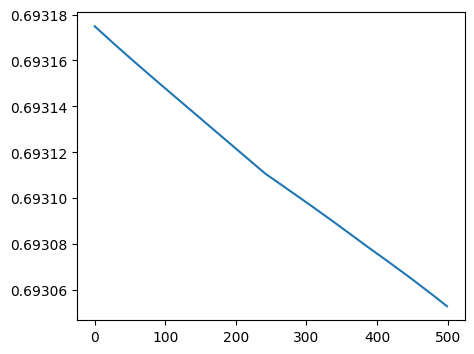

In [11]:
plt.figure(figsize=(5, 4))
plt.plot(ls_h)
plt.show()

<div align="">
    
**MohammadRzMahdyan**

<a href="https://github.com/MohammadRzMahdyan">
  <img src="https://img.shields.io/badge/GitHub-MohammadRzMahdyan-black?logo=github&logoColor=white" />
</a>
<br/>
</div>